In [614]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

Q1: Dataset Preparation

The dataset is read and converted into a numerical matrix suitable for training.

Preprocessing steps:
- Load dataset
- Handle missing values
- Separate feature matrix X and target vector y

Each row represents one example and the last column represents the target label.

In [615]:
cols=["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
clv_df=pd.read_csv(r"E:\AI-ML LAB\heart_disease\processed.cleveland.data",sep=',',header=None,names=cols)
hung_df=pd.read_csv(r"E:\AI-ML LAB\heart_disease\processed.hungarian.data",sep=',',header=None,names=cols)
switz_df=pd.read_csv(r"E:\AI-ML LAB\heart_disease\processed.switzerland.data",sep=',',header=None,names=cols)
va_df=pd.read_csv(r"E:\AI-ML LAB\heart_disease\processed.va.data",sep=',',header=None,names=cols)

In [616]:
clv_df.replace(['?'], np.nan, inplace=True)
clv_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [617]:
hung_df.replace(['?'], np.nan, inplace=True)
hung_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,NaN,NaN,NaN,0
1,29,1,2,120,243,0,0,160,0,0.0,NaN,NaN,NaN,0
2,29,1,2,140,NaN,0,0,170,0,0.0,NaN,NaN,NaN,0
3,30,0,1,170,237,0,1,170,0,0.0,NaN,NaN,6,0
4,31,0,2,100,219,0,1,150,0,0.0,NaN,NaN,NaN,0


In [618]:
switz_df.replace(['?'], np.nan, inplace=True)
switz_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,1,95,0,NaN,0,127,0,.7,1,NaN,NaN,1
1,34,1,4,115,0,NaN,NaN,154,0,.2,1,NaN,NaN,1
2,35,1,4,NaN,0,NaN,0,130,1,NaN,NaN,NaN,7,3
3,36,1,4,110,0,NaN,0,125,1,1,2,NaN,6,1
4,38,0,4,105,0,NaN,0,166,0,2.8,1,NaN,NaN,2


In [619]:
va_df.replace(['?'], np.nan, inplace=True)
va_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,4,140,260,0,1,112,1,3,2,NaN,NaN,2
1,44,1,4,130,209,0,1,127,0,0,NaN,NaN,NaN,0
2,60,1,4,132,218,0,1,140,1,1.5,3,NaN,NaN,2
3,55,1,4,142,228,0,1,149,1,2.5,1,NaN,NaN,1
4,66,1,3,110,213,1,2,99,1,1.3,2,NaN,NaN,0


In [620]:
clv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    object 
 12  thal      301 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [621]:
hung_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  293 non-null    object 
 4   chol      271 non-null    object 
 5   fbs       286 non-null    object 
 6   restecg   293 non-null    object 
 7   thalach   293 non-null    object 
 8   exang     293 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    object 
 11  ca        3 non-null      object 
 12  thal      28 non-null     object 
 13  num       294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


In [622]:
switz_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       123 non-null    int64 
 1   sex       123 non-null    int64 
 2   cp        123 non-null    int64 
 3   trestbps  121 non-null    object
 4   chol      123 non-null    int64 
 5   fbs       48 non-null     object
 6   restecg   122 non-null    object
 7   thalach   122 non-null    object
 8   exang     122 non-null    object
 9   oldpeak   117 non-null    object
 10  slope     106 non-null    object
 11  ca        5 non-null      object
 12  thal      71 non-null     object
 13  num       123 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 13.6+ KB


In [623]:
va_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       200 non-null    int64 
 1   sex       200 non-null    int64 
 2   cp        200 non-null    int64 
 3   trestbps  144 non-null    object
 4   chol      193 non-null    object
 5   fbs       193 non-null    object
 6   restecg   200 non-null    int64 
 7   thalach   147 non-null    object
 8   exang     147 non-null    object
 9   oldpeak   144 non-null    object
 10  slope     98 non-null     object
 11  ca        2 non-null      object
 12  thal      34 non-null     object
 13  num       200 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 22.0+ KB


In [624]:
cols.remove("slope")
cols.remove("ca")
cols.remove("thal")

In [625]:
clv_drp=clv_df.drop(columns=["slope","ca","thal"])
clv_pcsd=clv_drp.dropna().reset_index(drop=True).astype(float)
len(clv_pcsd)

303

In [626]:
switz_drp=switz_df.drop(columns=["slope","ca","thal"])
switz_pcsd=switz_drp.dropna().reset_index(drop=True).astype(float)
len(switz_pcsd)

46

In [627]:
va_drp=va_df.drop(columns=["slope","ca","thal"])
va_pcsd=va_drp.dropna().reset_index(drop=True).astype(float)
len(va_pcsd)

130

In [628]:
hung_drp=hung_df.drop(columns=["slope","ca","thal"])
hung_pcsd=hung_drp.dropna().reset_index(drop=True).astype(float)
len(hung_pcsd)

261

In [629]:
df=pd.concat([clv_pcsd,hung_pcsd,switz_pcsd,va_pcsd]).reset_index(drop=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0
...,...,...,...,...,...,...,...,...,...,...,...
735,62.0,1.0,4.0,158.0,170.0,0.0,1.0,138.0,1.0,0.0,1.0
736,46.0,1.0,4.0,134.0,310.0,0.0,0.0,126.0,0.0,0.0,2.0
737,54.0,0.0,4.0,127.0,333.0,1.0,1.0,154.0,0.0,0.0,1.0
738,55.0,1.0,4.0,122.0,223.0,1.0,1.0,100.0,0.0,0.0,2.0


In [630]:
xor_data=pd.DataFrame([[0,0,0],
                       [0,1,1],
                       [1,0,1],
                       [1,1,0]],columns=["x1","x2","y"])
xor_data

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [631]:
xnor_data=xor_data.copy()
xnor_data["y"]=1-xor_data["y"].copy()
xnor_data

,x1,x2,y
0,0,0,1
1,0,1,0
2,1,0,0
3,1,1,1


## MLP Implementation (Solution Class)

This class implements a generic Multilayer Perceptron (MLP) using the Backpropagation learning algorithm.  
The network supports configurable architecture, training parameters, and dataset splits.

### Network Structure

The MLP consists of:
- **Input layer**: receives feature vector x
- **Hidden layers**: perform nonlinear transformations
- **Output layer**: produces final prediction

Each neuron computes:

y = sigmoid( Σ(w_i x_i) )

where  
x_i → input values  
w_i → weights  
y → neuron output

The sigmoid activation is used:
                        sigmoid(z) = 1 / (1 + e^{-z})

---
# Important Variables

**n_in**  
Number of input features in the dataset.

**n_out**  
Number of output nodes (number of classes).

**num_hidden_layers**  
Number of hidden layers in the network.

**n_hidden**  
Array storing number of neurons in each hidden layer.

Example:  
[5,3] → first hidden layer has 5 neurons, second has 3.

---

**weights**
List of weight matrices between layers.
weights[i] represents connections from layer i → layer i+1
Shape:
layer_i_nodes × layer_(i+1)_nodes

---
**biases**
Bias vectors for each layer.
Each neuron has one bias value added before activation.

---
**learning_rate (η)**
Controls the magnitude of weight updates during training.

---
**alpha**
Learning rate decay factor.
Used to gradually reduce learning rate.
η = η * α

---
**LR_decay_freq**
Number of iterations after which learning rate decay is applied.

---
**maxIter**
Maximum number of training iterations allowed.Prevents infinite training loops.

---
**maxErr**
Maximum acceptable classification error (%) on the test set. Training stops when this error threshold is reached.

---
**percentOverfit**
Maximum allowed difference between training accuracy and validation accuracy.Used to detect overfitting.

---
# Main Functions

### 1. Initialization
Creates the network architecture based on the input parameters and initializes weight matrices and bias vectors.

---
### 2. Forward Propagation
Propagates the input through the network layer by layer.
Steps:
1. Multiply inputs with weights
2. Add bias
3. Apply sigmoid activation
Outputs of each layer are stored for use during backpropagation.

---
### 3. Backpropagation
Computes error gradients and updates weights.
Steps:
1. Compute output layer error
δ_k = o_k (1 - o_k)(t_k - o_k)

2. Compute hidden layer errors
δ_h = o_h (1 - o_h) Σ(w_kh δ_k)

3. Update weights
w_ji ← w_ji + η δ_j x_ji

---
### 4. Training Loop
For each iteration:
1. Perform forward propagation
2. Compute prediction error
3. Perform backpropagation
4. Update weights
5. Check stopping conditions

Training stops when:
- maxIter is reached
- test error ≤ maxErr
- overfitting threshold exceeded
---
### 5. Prediction-
Uses forward propagation with the learned weights to produce class predictions for new inputs.

In [632]:
class MLP:
    def __init__(self,Examples,num_hidden_layers=1,n_hidden=[2],lr=0.01,random_init=True,initial_val=0,alpha=1,lr_decay_freq=np.inf,maxIter=1000,maxErr=0,percentOverfit=100,train_seg=70,val_seg=10,confusion_flag=False):
        self.Examples=Examples
        self.num_hidden_layers=num_hidden_layers
        self.n_hidden=n_hidden
        self.lr=lr
        self.alpha=alpha
        self.lr_decay_freq=lr_decay_freq
        self.maxIter=maxIter
        self.maxErr=maxErr
        self.percentOverfit=percentOverfit
        self.train_seg=train_seg
        self.val_seg=val_seg
        self.n_in=Examples.shape[1]-1
        tmp=Examples.iloc[:,-1].nunique() 
        self.n_out=tmp if tmp!=2 else 1
        self.weights=[]
        self.train_error_hist=[]
        self.val_error_hist=[]
        self.test_error_hist=[]
        self.w_hist=[]
        self.random_init=random_init
        self.initial_val=float(initial_val)
        self.itr=1
        self.conf_flag=confusion_flag
        self.train=None
        self.val=None
        self.test=None
        
    def initialise_weights(self,initial_val):
        if(self.num_hidden_layers>0):
            wt=[np.full((self.n_in+1,self.n_hidden[0]),initial_val)]
            for i in range(self.num_hidden_layers-1):
                wt.append(np.full((self.n_hidden[i]+1,self.n_hidden[i+1]),initial_val))
            wt.append(np.full((self.n_hidden[-1]+1,self.n_out),initial_val))
        else:
            wt=[np.full((self.n_in+1,self.n_out),initial_val)]
        self.weights=wt

    def initialise_weights_random(self):
        if(self.num_hidden_layers>0):
            wt=[0.1*np.random.randn(self.n_in+1,self.n_hidden[0])]
            for i in range(self.num_hidden_layers-1):
                wt.append(0.1*np.random.randn(self.n_hidden[i]+1,self.n_hidden[i+1]))
            wt.append(0.1*np.random.randn(self.n_hidden[-1]+1,self.n_out))
        else:
            wt=[0.1*np.random.randn(self.n_in+1,self.n_out)]
        self.weights=wt
    
    def sigmoid(self,z):
        return 1/(1+np.exp(-z))

    def forward_prop(self,x0):
        x=[np.append(1,np.array(x0,dtype=float))] #x0, adding 1 for bias
        o=[]
        for i in range(self.num_hidden_layers):
            o.append(self.sigmoid(x[i]@self.weights[i]))
            x.append(np.append(1,o[i]))
        o.append(self.sigmoid(x[-1]@self.weights[-1]))
        return o,x
        
    def backprop(self,out,target):
        delta=[[]for i in range(len(out))]
        delta[-1]=np.array(out[-1]*(np.ones_like(out[-1])-out[-1])*(target-out[-1]))
        for i in range(len(out)-2,-1,-1):
            delta[i]=np.array((out[i]*(np.ones_like(out[i])-out[i]))*(self.weights[i+1][1:]@delta[i+1]))
        return delta

    def weight_update(self,x,delta):
        for i in range(len(x)):
            delw=self.lr*x[i].reshape(-1,1)@delta[i].reshape(-1,1).T
            self.weights[i]+=delw

    def train_val_test_split(self,Examples):
        Examples=Examples.sample(frac=1).reset_index(drop=True)
        train=Examples.iloc[:int(self.train_seg*len(Examples)/100)]
        val=Examples.iloc[int(self.train_seg*len(Examples)/100):int(self.train_seg*len(Examples)/100)+int(self.val_seg*len(Examples)/100):]
        test=Examples.iloc[int(self.train_seg*len(Examples)/100)+int(self.val_seg*len(Examples)/100):]
        return train,val,test
    
    def predict(self,xpred):
        output,_=self.forward_prop(xpred)
        if(self.n_out>1):
            return np.argmax(output[-1])
        else:
            return 1 if output[-1]>0.5 else 0

    def predicted_df(self):
        copied_df=self.Examples.copy()
        x,y=copied_df.iloc[:,:-1],copied_df.iloc[:,-1]
        ypred=[]
        for i in range(len(x)):
            ypred.append(self.predict(x.iloc[i]))
        target=copied_df.columns[-1]
        copied_df.rename(columns={target:"y_actual"},inplace=True)
        copied_df["y_predicted"]=ypred
        return copied_df
            
    def find_accuracy(self,x,y):
        if(len(x)==0):
            return 0
        correct=0
        for i in range(len(x)):
            ypred=self.predict(x.iloc[i])
            if(ypred==y.iloc[i]):
                correct+=1
        return correct*100/len(x)

    def confusion_mat(self,x,y):
        if(len(x)==0):
            return []
        tp,tn,fn,fp=0,0,0,0
        for i in range(len(x)):
            ypred=self.predict(x.iloc[i])
            if(ypred==y.iloc[i]):
                if(ypred==1):
                    tp+=1
                else:
                    tn+=1
            else:
                if(ypred==0):
                    fn+=1
                else:
                    fp+=1
        mat=np.array([[tp,fp],
                     [fn,tn]])
        print("\nConfusion Matrix:-")
        print(" [TP FP] : ",mat[0])
        print(" [FN TN] : ", mat[1])
        
    def find_mse_err(self, x, y):
        s = 0
        for i in range(len(x)):
            ypred, _ = self.forward_prop(x.iloc[i])
            if self.n_out > 1:
                y_enc = np.zeros(self.n_out)
                y_enc[int(y.iloc[i])] = 1
                s += 0.5 * np.sum((ypred[-1] - y_enc)**2)
            else:
                s += 0.5 * (ypred[-1][0] - y.iloc[i])**2
        return s
    
    def plot_error(self,error):
        plt.plot(np.linspace(1,self.itr,self.itr),error,c='red')
        plt.xlabel("Iterations")
        plt.ylabel("Squared Error ( Σ 0.5 * (y_actual - y_predicted)² ) ")
        plt.title("Squared Error ( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
        plt.show()

    def onehotencoder(self,y):
        yenc=np.zeros((len(y),self.n_out))
        for i in range(len(y)):
            yenc[i,int(y.iloc[i])]=1
        return pd.DataFrame(yenc,columns=[str(i) for i in range(self.n_out)])
    
    def plot_weights(self):
        fig, axes = plt.subplots(1, len(self.weights), figsize=(12, 5))
        if len(self.weights) == 1:
            axes = [axes]
        
        layer_names = []
        layer_names.append(f"W1: Input-->Hidden\n({self.weights[0].shape[0]}×{self.weights[0].shape[1]})")
        for i in range(1, len(self.weights)-1):
            layer_names.append(f"W{i+1}: Hidden{i}-->Hidden{i+1}\n({self.weights[i].shape[0]}×{self.weights[i].shape[1]})")
        layer_names.append(f"W{len(self.weights)}: Hidden-->Output\n({self.weights[-1].shape[0]}×{self.weights[-1].shape[1]})")
        
        for i, (w, name) in enumerate(zip(self.weights, layer_names)):
            im = axes[i].imshow(w, cmap='gray', aspect='auto')
            axes[i].set_title(name)
            axes[i].set_xlabel("Neurons in next layer")
            axes[i].set_ylabel("Neurons in current layer\n(row 0 = bias)")
            plt.colorbar(im, ax=axes[i])
    
        plt.suptitle("Weight Matrices as Images")
        plt.tight_layout()
        plt.show()
    
    def main(self):
        np.random.seed(0)
        self.train_error_hist=[]
        self.val_error_hist=[]
        self.test_error_hist=[]
        self.w_hist=[]
        self.train,self.val,self.test=self.train_val_test_split(self.Examples)
        x_train=self.train.iloc[:,:-1]
        x_val=self.val.iloc[:,:-1]
        x_test=self.test.iloc[:,:-1]
        y_train=self.train.iloc[:,-1]
        y_val=self.val.iloc[:,-1]
        y_test=self.test.iloc[:,-1]
        if(self.n_out>1):
            y_train_enc=self.onehotencoder(self.train.iloc[:,-1])
            y_val_enc=self.onehotencoder(self.val.iloc[:,-1])
            y_test_enc=self.onehotencoder(self.test.iloc[:,-1])
        self.itr=1
        if(self.random_init):
            self.initialise_weights_random()
        else:
            self.initialise_weights(self.initial_val)
        flag=0
        accuracy_train,accuracy_val=0,0
        error_test=0
        print(f"Training the Multi-Layer Perceptron:-")
        while True:
                self.train_error_hist.append(self.find_mse_err(x_train,y_train))
                self.val_error_hist.append(self.find_mse_err(x_val,y_val))
                self.test_error_hist.append(self.find_mse_err(x_test,y_test))
                self.w_hist.append(deepcopy(self.weights))
                for i in range(len(x_train.values)):
                    out,x_mat=self.forward_prop(x_train.iloc[i])
                    if(self.n_out>1):
                        delta=self.backprop(out,y_train_enc.iloc[i])
                    else:
                        delta=self.backprop(out,y_train.iloc[i])
                    self.weight_update(x_mat,delta)
                accuracy_train=self.find_accuracy(x_train,y_train)
                accuracy_val=self.find_accuracy(x_val,y_val)
                error_test=100-self.find_accuracy(x_test,y_test) #question explicitly asks to calc error on test data
                per_overfit=np.abs(accuracy_train-accuracy_val)
                overfit_condition = (per_overfit >= self.percentOverfit) if len(x_val) > 0 else False
                error_condition = (error_test <= self.maxErr) if len(x_test) > 0 else False
                print(f"Iteration {self.itr}....\tTraining Accuracy={accuracy_train} \t Validation Accuracy={accuracy_val}",end='\r')
                if(self.itr%20==0 and self.conf_flag):
                    self.confusion_mat(x_test,y_test)
                if(self.itr%self.lr_decay_freq==0):
                        self.lr=self.lr*self.alpha
                if(self.itr>=self.maxIter or error_condition or overfit_condition):
                    print(f"\nTraining ends at iteration no. {self.itr}")
                    break
                self.itr+=1
        if(len(x_test)>0):
            print("Error% on the Testing Data:",error_test)
        

## XOR Prediction for 1 hidden layer with 2 nodes(Additional)

In [633]:
xorr=MLP(xor_data,num_hidden_layers=1,n_hidden=[2],maxIter=2000,lr=0.5,train_seg=100,val_seg=0)
xorr.main()
xorr.predicted_df()

Training the Multi-Layer Perceptron:-
Iteration 2000....	Training Accuracy=100.0 	 Validation Accuracy=0
Training ends at iteration no. 2000


,x1,x2,y_actual,y_predicted
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,0,0


## Learning the XOR Function

The network is first tested on the 2-bit XOR logical operation.

XOR mapping:

(0,0) → 0  
(0,1) → 1  
(1,0) → 1  
(1,1) → 0

The XOR problem is **linearly inseparable**, meaning it cannot be solved using a single linear decision boundary. Neural networks learn this relationship through nonlinear activation functions.

In [634]:
ques3=MLP(xor_data,num_hidden_layers=0,n_hidden=[],random_init=True,lr=0.1,alpha=1,lr_decay_freq=50,maxIter=2000,train_seg=100,val_seg=0)
ques3.main()
ques3.predicted_df()

Training the Multi-Layer Perceptron:-
Iteration 2000....	Training Accuracy=50.0 	 Validation Accuracy=0
Training ends at iteration no. 2000


,x1,x2,y_actual,y_predicted
0,0,0,0,0
1,0,1,1,0
2,1,0,1,0
3,1,1,0,0


In [635]:
ques3.confusion_mat(xor_data.iloc[:,:-1],xor_data.iloc[:,-1])


Confusion Matrix:-
 [TP FP] :  [0 0]
 [FN TN] :  [2 2]


### Prediction Error over Iterations

Total prediction error is plotted across iterations to observe how quickly the network converges. A decreasing error indicates that the network is learning the XOR relationship.

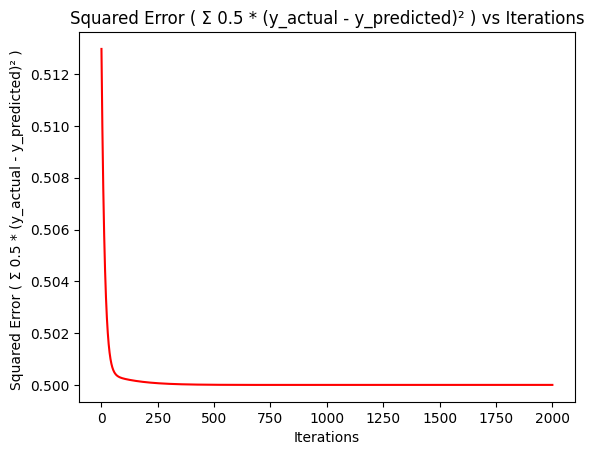

In [636]:
ques3.plot_error(ques3.train_error_hist)

### Weight Evolution

The values of network weights are plotted across iterations.

Observing these plots helps understand how parameters adjust during training and stabilize as the network converges.

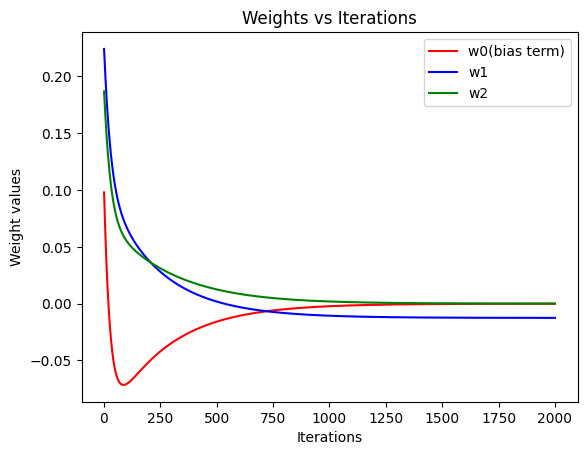

In [637]:
plt.plot(np.linspace(1,ques3.itr,ques3.itr),np.array(ques3.w_hist)[:, 0, 0, 0],c='red',label="w0(bias term)")
plt.plot(np.linspace(1,ques3.itr,ques3.itr),np.array(ques3.w_hist)[:, 0, 1, 0],c='blue',label="w1")
plt.plot(np.linspace(1,ques3.itr,ques3.itr),np.array(ques3.w_hist)[:, 0, 2, 0],c='green',label="w2")
plt.xlabel("Iterations")
plt.ylabel("Weight values")
plt.title("Weights vs Iterations")
plt.legend()
plt.show()

### Q3b Learned Network Representation

After training, the final weights define the learned function:

y = sigmoid( Σ w_i x_i )

These learned parameters determine how the network separates the XOR classes.

In [638]:
w0=ques3.weights[0][0][0]
w1=ques3.weights[0][1][0]
w2=ques3.weights[0][2][0]
equation_xor_q3=f"y = sigmoid({w1:.3f}*x1 + {w2:.3f}*x2 + {w0:.3f})"
print("Equation:",equation_xor_q3)

Equation: y = sigmoid(-0.013*x1 + 0.000*x2 + -0.000)


### Q3c: Effect of Changing the Order of Training Examples

Changing the order of training examples can affect the training trajectory because the network updates weights sequentially after each example. Different orders may lead to different intermediate weight values and convergence paths.

However, since the XOR dataset is very small and the solution space is limited, the final learned parameters and decision boundary typically remain similar after sufficient training.

In [639]:
ques3_shuf=MLP(xor_data.sample(frac=1),num_hidden_layers=0,n_hidden=[],random_init=True,lr=0.1,alpha=1,lr_decay_freq=np.inf,maxIter=2000,train_seg=100,val_seg=0)
ques3_shuf.main()
ques3_shuf.predicted_df()

Training the Multi-Layer Perceptron:-
Iteration 2000....	Training Accuracy=50.0 	 Validation Accuracy=0
Training ends at iteration no. 2000


,x1,x2,y_actual,y_predicted
1,0,1,1,1
3,1,1,0,1
2,1,0,1,0
0,0,0,0,0


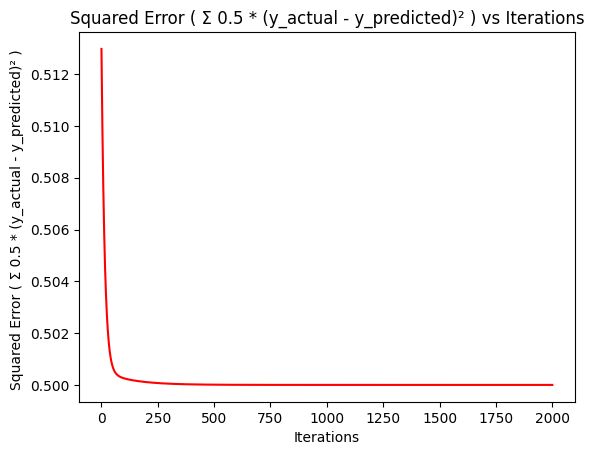

In [640]:
ques3_shuf.plot_error(ques3_shuf.train_error_hist)

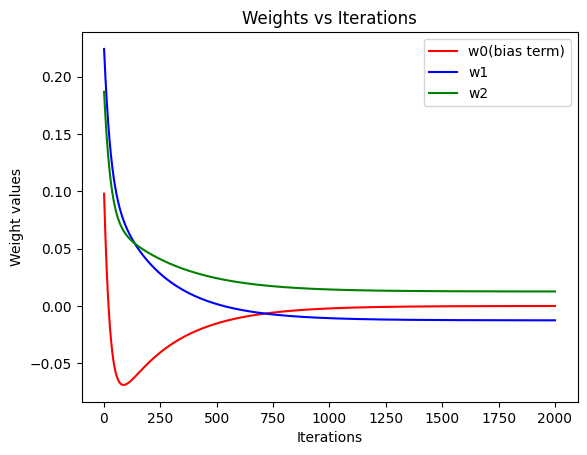

In [641]:
plt.plot(np.linspace(1,ques3_shuf.itr,ques3_shuf.itr),np.array(ques3_shuf.w_hist)[:, 0, 0, 0],c='red',label="w0(bias term)")
plt.plot(np.linspace(1,ques3_shuf.itr,ques3_shuf.itr),np.array(ques3_shuf.w_hist)[:, 0, 1, 0],c='blue',label="w1")
plt.plot(np.linspace(1,ques3_shuf.itr,ques3_shuf.itr),np.array(ques3_shuf.w_hist)[:, 0, 2, 0],c='green',label="w2")
plt.xlabel("Iterations")
plt.ylabel("Weight values")
plt.title("Weights vs Iterations")
plt.legend()
plt.show()

## Learning the XNOR Function

The same network is trained on the XNOR logical operation.

XNOR is the complement of XOR:

(0,0) → 1  
(0,1) → 0  
(1,0) → 0  
(1,1) → 1

The final learned weights are compared with those obtained for XOR to observe how the decision boundary changes.

In [642]:
xnor_ques3=MLP(xnor_data,num_hidden_layers=0,n_hidden=[],random_init=True,lr=0.1,alpha=1,lr_decay_freq=np.inf,maxIter=2000,train_seg=100,val_seg=0)
xnor_ques3.main()

Training the Multi-Layer Perceptron:-
Iteration 2000....	Training Accuracy=50.0 	 Validation Accuracy=0
Training ends at iteration no. 2000


In [643]:
w0_xnor=xnor_ques3.weights[0][0][0]
w1_xnor=xnor_ques3.weights[0][1][0]
w2_xnor=xnor_ques3.weights[0][2][0]
equation_xnor_q3=f"y = sigmoid({w1_xnor:.3f}*x1 + {w2_xnor:.3f}*x2 + {w0_xnor:.3f})"
print("Equation:",equation_xnor_q3)

Equation: y = sigmoid(0.013*x1 + 0.000*x2 + -0.000)


### Comparison of the equations for XOR and XNOR:
The difference in the weights for XOR and XNOR can be seen:
The signs for the wights are reversed for XNOR

In [644]:
print("Equation for XOR:",equation_xor_q3)
print("Equation for XNOR:",equation_xnor_q3)

Equation for XOR: y = sigmoid(-0.013*x1 + 0.000*x2 + -0.000)
Equation for XNOR: y = sigmoid(0.013*x1 + 0.000*x2 + -0.000)


## Q4. Heart Disease Classification

The MLP model is now applied to the heart disease dataset for binary classification:

Healthy → target = 0  
Disease present → target > 0

The network learns patterns in the input features that indicate the presence of heart disease.

In [645]:
clv_q4=clv_pcsd.copy()
clv_q4["target"]=[1 if x>=1  else 0 for x in clv_q4[cols[-1]]]
clv_q4.drop(columns=[cols[-1]],inplace=True)
clv_q4.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0


In [646]:
hung_q4=hung_pcsd.copy()
hung_q4["target"]=[1 if x>=1  else 0 for x in hung_q4[cols[-1]]]
hung_q4.drop(columns=[cols[-1]],inplace=True)
hung_q4.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
3,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0
4,32.0,0.0,2.0,105.0,198.0,0.0,0.0,165.0,0.0,0.0,0


In [647]:
switz_q4=switz_pcsd.copy()
switz_q4["target"]=[1 if x>=1  else 0 for x in switz_q4[cols[-1]]]
switz_q4.drop(columns=[cols[-1]],inplace=True)
switz_q4.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,38.0,0.0,4.0,110.0,0.0,0.0,0.0,156.0,0.0,0.0,1
1,38.0,1.0,3.0,115.0,0.0,0.0,0.0,128.0,1.0,0.0,1
2,42.0,1.0,4.0,145.0,0.0,0.0,0.0,99.0,1.0,0.0,1
3,43.0,1.0,4.0,115.0,0.0,0.0,0.0,145.0,1.0,2.0,1
4,43.0,1.0,4.0,140.0,0.0,0.0,1.0,140.0,1.0,0.5,1


In [648]:
va_q4=va_pcsd.copy()
va_q4["target"]=[1 if x>=1  else 0 for x in va_q4[cols[-1]]]
va_q4.drop(columns=[cols[-1]],inplace=True)
va_q4.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,63.0,1.0,4.0,140.0,260.0,0.0,1.0,112.0,1.0,3.0,1
1,44.0,1.0,4.0,130.0,209.0,0.0,1.0,127.0,0.0,0.0,0
2,60.0,1.0,4.0,132.0,218.0,0.0,1.0,140.0,1.0,1.5,1
3,55.0,1.0,4.0,142.0,228.0,0.0,1.0,149.0,1.0,2.5,1
4,66.0,1.0,3.0,110.0,213.0,1.0,2.0,99.0,1.0,1.3,0


In [649]:
df_q4=df.copy()
df_q4["target"]=[1 if x>=1  else 0 for x in df_q4[cols[-1]]]
df_q4.drop(columns=[cols[-1]],inplace=True)
df_q4

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
735,62.0,1.0,4.0,158.0,170.0,0.0,1.0,138.0,1.0,0.0,1
736,46.0,1.0,4.0,134.0,310.0,0.0,0.0,126.0,0.0,0.0,1
737,54.0,0.0,4.0,127.0,333.0,1.0,1.0,154.0,0.0,0.0,1
738,55.0,1.0,4.0,122.0,223.0,1.0,1.0,100.0,0.0,0.0,1


In [650]:
clv_q4_scal = clv_q4.copy()
mean = clv_q4_scal.iloc[:,:-1].mean()
std = clv_q4_scal.iloc[:,:-1].std(ddof=0)  
clv_q4_scal.iloc[:,:-1] = (clv_q4_scal.iloc[:,:-1] - mean) / std

In [651]:
hung_q4_scal=hung_q4.copy()
hung_q4_scal.iloc[:,:-1] = (hung_q4_scal.iloc[:,:-1] - mean) / std
switz_q4_scal=switz_q4.copy()
switz_q4_scal.iloc[:,:-1] = (switz_q4_scal.iloc[:,:-1] - mean) / std
va_q4_scal=va_q4.copy()
va_q4_scal.iloc[:,:-1] = (va_q4_scal.iloc[:,:-1] - mean) / std

## Q4: ANN Classifier for Heart Disease Dataset Prediction

The MLP model is trained to perform binary classification for heart disease detection.

Target definition:
- Healthy → target = 0
- Heart disease → target > 0

Network configuration (Setting-1):

- Hidden layers = 1  
- Hidden nodes = [5]  
- Learning rate η = 0.1  
- No learning rate decay  
- maxIter = 100  
- maxErr = 5  
- percentOverfit = 30  
- Dataset split = 80% training, 10% validation, 10% testing  

All layers use sigmoid activation and are fully connected.  
All weights are initialized to zero.

### Q4b: Confusion Matrix

A confusion matrix is computed every 20 iterations for the testing dataset.

The matrix contains:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

It provides a detailed view of classification performance beyond overall accuracy.

In [652]:
model_clv_q4=MLP(clv_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=1,random_init=False,confusion_flag=True,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_clv_q4.main()

Training the Multi-Layer Perceptron:-
Iteration 20....	Training Accuracy=82.23140495867769 	 Validation Accuracy=80.03333333333333
Confusion Matrix:-
 [TP FP] :  [12  3]
 [FN TN] :  [ 3 13]
Iteration 40....	Training Accuracy=82.23140495867769 	 Validation Accuracy=76.66666666666667
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]
Iteration 60....	Training Accuracy=81.81818181818181 	 Validation Accuracy=80.06666666666667
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]
Iteration 80....	Training Accuracy=81.81818181818181 	 Validation Accuracy=80.0
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]
Iteration 100....	Training Accuracy=82.23140495867769 	 Validation Accuracy=80.0
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]

Training ends at iteration no. 100
Error% on the Testing Data: 22.58064516129032


### Q4a: Error vs Iterations

Training, validation, and testing errors are plotted for every iteration.

These plots help analyze:
- how quickly the model converges
- whether the model is learning meaningful patterns
- whether overfitting occurs when validation error increases while training error decreases

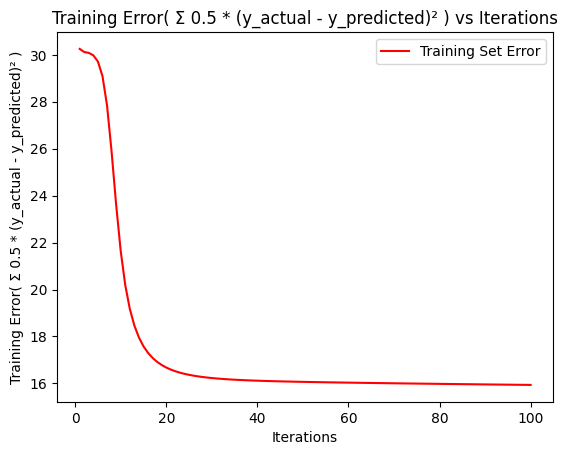

In [653]:
x=np.linspace(1,model_clv_q4.itr,model_clv_q4.itr)
plt.plot(x,np.array(model_clv_q4.train_error_hist),c='red',label="Training Set Error")
plt.xlabel("Iterations")
plt.ylabel("Training Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Training Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

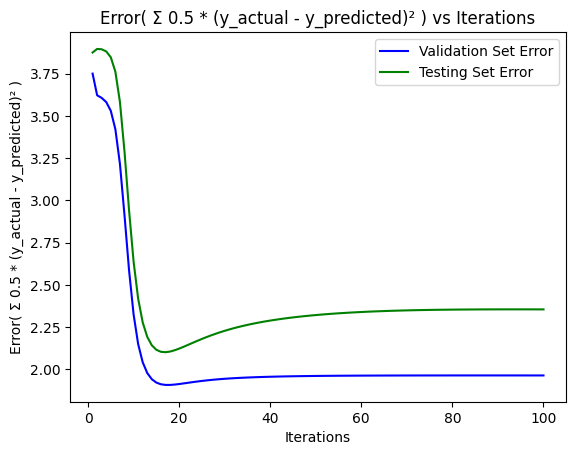

In [654]:
plt.plot(x,np.array(model_clv_q4.val_error_hist),c='blue',label="Validation Set Error")
plt.plot(x,np.array(model_clv_q4.test_error_hist),c='green',label="Testing Set Error")
plt.xlabel("Iterations")
plt.ylabel("Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

### Q4c: Weight Matrix Visualization

The weight matrices between consecutive layers are visualized as 2D images.

These visualizations help observe how input features influence hidden neurons and how the network structure evolves during learning.

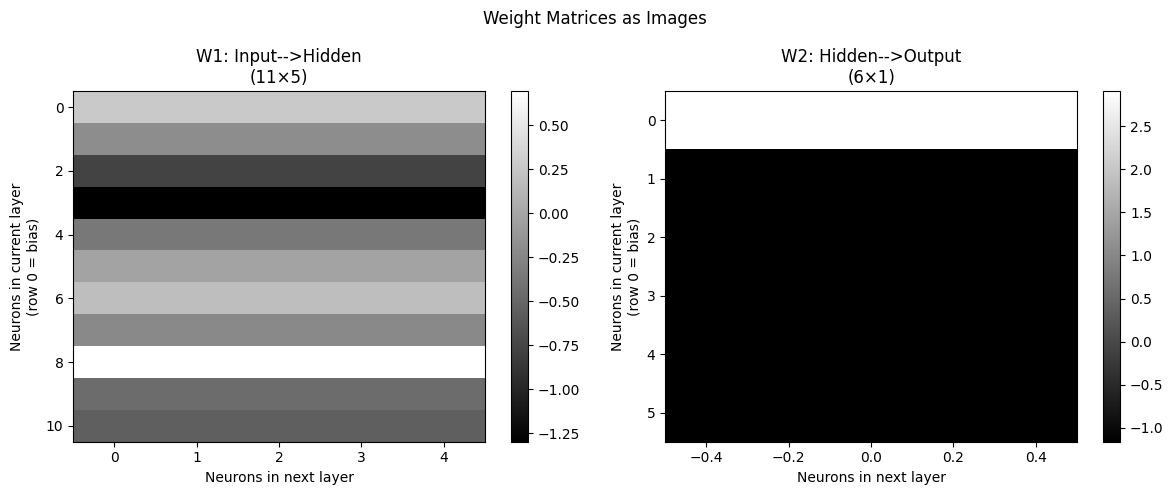

In [655]:
model_clv_q4.plot_weights()

# With Random Initialisation instead of 0

In [656]:
model_clv_q4_2=MLP(clv_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=1,random_init=True,confusion_flag=False,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_clv_q4_2.main()

Training the Multi-Layer Perceptron:-
Iteration 100....	Training Accuracy=84.29752066115702 	 Validation Accuracy=86.66666666666667
Training ends at iteration no. 100
Error% on the Testing Data: 16.129032258064512


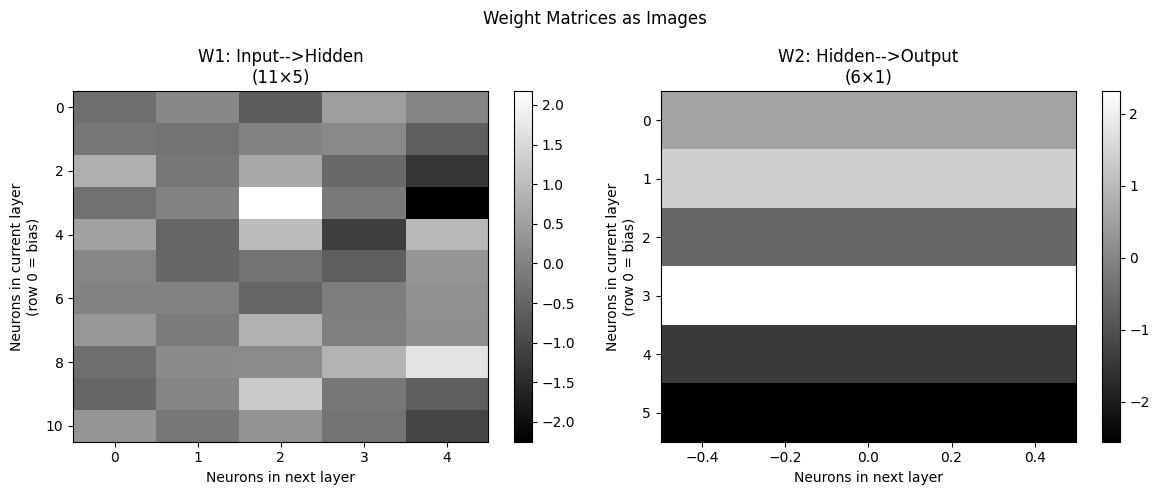

In [657]:
model_clv_q4_2.plot_weights()

### Q4d: Testing on Unseen Datasets

The model trained on the Cleveland dataset is tested on other datasets.


Confusion matrices are computed to evaluate how well the learned model generalizes to unseen data from different sources.

In [658]:
print("On Hungarian:-",end='')
model_clv_q4_2.confusion_mat(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1])
print("Accuracy:",model_clv_q4_2.find_accuracy(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1]))

On Hungarian:-
Confusion Matrix:-
 [TP FP] :  [76 30]
 [FN TN] :  [ 22 133]
Accuracy: 80.07662835249042


In [659]:
print("On Switzerland:-",end='')
model_clv_q4_2.confusion_mat(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1])
print("Accuracy :",model_clv_q4_2.find_accuracy(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1]))

On Switzerland:-
Confusion Matrix:-
 [TP FP] :  [39  0]
 [FN TN] :  [6 1]
Accuracy : 86.95652173913044


In [660]:
print("On VA:-",end='')
model_clv_q4_2.confusion_mat(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1])
print("Accuracy :",model_clv_q4_2.find_accuracy(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1]))

On VA:-
Confusion Matrix:-
 [TP FP] :  [89 23]
 [FN TN] :  [12  6]
Accuracy : 73.07692307692308


# Training using Hungarian

In [661]:
hung_q4_scal = hung_q4.copy()
mean = hung_q4_scal.iloc[:,:-1].mean()
std = hung_q4_scal.iloc[:,:-1].std(ddof=0)  
hung_q4_scal.iloc[:,:-1] = (hung_q4_scal.iloc[:,:-1] - mean) / std
clv_q4_scal=clv_q4.copy()
clv_q4_scal.iloc[:,:-1] = (clv_q4_scal.iloc[:,:-1] - mean) / std
switz_q4_scal=switz_q4.copy()
switz_q4_scal.iloc[:,:-1] = (switz_q4_scal.iloc[:,:-1] - mean) / std
va_q4_scal=va_q4.copy()
va_q4_scal.iloc[:,:-1] = (va_q4_scal.iloc[:,:-1] - mean) / std

In [662]:
model_hung=MLP(hung_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=1,random_init=True,confusion_flag=False,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_hung.main()

Training the Multi-Layer Perceptron:-
Iteration 100....	Training Accuracy=87.01923076923077 	 Validation Accuracy=76.92307692307692
Training ends at iteration no. 100
Error% on the Testing Data: 29.629629629629633


In [663]:
print("On Cleveland:-",end='')
model_hung.confusion_mat(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1])
print("Accuracy:",model_hung.find_accuracy(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1]))
print("\nOn Switzerland:-",end='')
model_hung.confusion_mat(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1])
print("Accuracy :",model_hung.find_accuracy(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1]))
print("\nOn VA:-",end='')
model_hung.confusion_mat(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1])
print("Accuracy :",model_hung.find_accuracy(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1]))

On Cleveland:-
Confusion Matrix:-
 [TP FP] :  [90 29]
 [FN TN] :  [ 49 135]
Accuracy: 74.25742574257426

On Switzerland:-
Confusion Matrix:-
 [TP FP] :  [11  0]
 [FN TN] :  [34  1]
Accuracy : 26.08695652173913

On VA:-
Confusion Matrix:-
 [TP FP] :  [74 12]
 [FN TN] :  [27 17]
Accuracy : 70.0


# Training using Switzerland

In [664]:
switz_q4_scal = switz_q4.copy()
mean = switz_q4_scal.iloc[:,:-1].mean()
std = switz_q4_scal.iloc[:,:-1].std(ddof=0).replace(0,1)  
switz_q4_scal.iloc[:,:-1] = (switz_q4_scal.iloc[:,:-1] - mean) / std
clv_q4_scal=clv_q4.copy()
clv_q4_scal.iloc[:,:-1] = (clv_q4_scal.iloc[:,:-1] - mean) / std
hung_q4_scal=hung_q4.copy()
hung_q4_scal.iloc[:,:-1] = (hung_q4_scal.iloc[:,:-1] - mean) / std
va_q4_scal=va_q4.copy()
va_q4_scal.iloc[:,:-1] = (va_q4_scal.iloc[:,:-1] - mean) / std

In [665]:
model_switz=MLP(switz_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=1,random_init=True,confusion_flag=True,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_switz.main()

Training the Multi-Layer Perceptron:-
Iteration 1....	Training Accuracy=97.22222222222223 	 Validation Accuracy=100.0
Training ends at iteration no. 1
Error% on the Testing Data: 0.0


In [666]:
print("On Cleveland:-",end='')
model_switz.confusion_mat(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1])
print("Accuracy:",model_switz.find_accuracy(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1]))
print("\nOn Hungarian:-",end='')
model_switz.confusion_mat(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1])
print("Accuracy :",model_switz.find_accuracy(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1]))
print("\nOn VA:-",end='')
model_switz.confusion_mat(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1])
print("Accuracy :",model_switz.find_accuracy(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1]))

On Cleveland:-
Confusion Matrix:-
 [TP FP] :  [139 164]
 [FN TN] :  [0 0]
Accuracy: 45.87458745874587

On Hungarian:-
Confusion Matrix:-
 [TP FP] :  [ 98 163]
 [FN TN] :  [0 0]
Accuracy : 37.547892720306514

On VA:-
Confusion Matrix:-
 [TP FP] :  [101  29]
 [FN TN] :  [0 0]
Accuracy : 77.6923076923077


# Training using VA

In [667]:
va_q4_scal = va_q4.copy()
mean = va_q4_scal.iloc[:,:-1].mean()
std = va_q4_scal.iloc[:,:-1].std(ddof=0).replace(0,1)  
va_q4_scal.iloc[:,:-1] = (va_q4_scal.iloc[:,:-1] - mean) / std
clv_q4_scal=clv_q4.copy()
clv_q4_scal.iloc[:,:-1] = (clv_q4_scal.iloc[:,:-1] - mean) / std
switz_q4_scal=switz_q4.copy()
switz_q4_scal.iloc[:,:-1] = (switz_q4_scal.iloc[:,:-1] - mean) / std
hung_q4_scal=hung_q4.copy()
hung_q4_scal.iloc[:,:-1] = (hung_q4_scal.iloc[:,:-1] - mean) / std

In [668]:
model_va=MLP(va_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=1,random_init=True,confusion_flag=False,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_va.main()

Training the Multi-Layer Perceptron:-
Iteration 100....	Training Accuracy=84.61538461538461 	 Validation Accuracy=92.3076923076923
Training ends at iteration no. 100
Error% on the Testing Data: 30.769230769230774


In [669]:
print("On Cleveland:-",end='')
model_va.confusion_mat(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1])
print("Accuracy:",model_va.find_accuracy(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1]))
print("\nOn Hungarian:-",end='')
model_va.confusion_mat(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1])
print("Accuracy :",model_va.find_accuracy(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1]))
print("\nOn Switz:-",end='')
model_va.confusion_mat(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1])
print("Accuracy :",model_va.find_accuracy(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1]))

On Cleveland:-
Confusion Matrix:-
 [TP FP] :  [92 39]
 [FN TN] :  [ 47 125]
Accuracy: 71.61716171617162

On Hungarian:-
Confusion Matrix:-
 [TP FP] :  [83 39]
 [FN TN] :  [ 15 124]
Accuracy : 79.3103448275862

On Switz:-
Confusion Matrix:-
 [TP FP] :  [37  0]
 [FN TN] :  [8 1]
Accuracy : 82.6086956521739


In [670]:
df_q4_scal = df_q4.copy()
mean = df_q4_scal.iloc[:,:-1].mean()
std = df_q4_scal.iloc[:,:-1].std(ddof=0)  
df_q4_scal.iloc[:,:-1] = (df_q4_scal.iloc[:,:-1] - mean) / std
va_q4_scal=va_q4.copy()
va_q4_scal.iloc[:,:-1] = (va_q4_scal.iloc[:,:-1] - mean) / std
clv_q4_scal=clv_q4.copy()
clv_q4_scal.iloc[:,:-1] = (clv_q4_scal.iloc[:,:-1] - mean) / std
switz_q4_scal=switz_q4.copy()
switz_q4_scal.iloc[:,:-1] = (switz_q4_scal.iloc[:,:-1] - mean) / std
hung_q4_scal=hung_q4.copy()
hung_q4_scal.iloc[:,:-1] = (hung_q4_scal.iloc[:,:-1] - mean) / std

In [671]:
model_df=MLP(df_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=1,random_init=True,confusion_flag=True,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_df.main()

Training the Multi-Layer Perceptron:-
Iteration 20....	Training Accuracy=80.74324324324324 	 Validation Accuracy=83.78378378378379
Confusion Matrix:-
 [TP FP] :  [31  8]
 [FN TN] :  [ 6 29]
Iteration 40....	Training Accuracy=80.91216216216216 	 Validation Accuracy=82.43243243243244
Confusion Matrix:-
 [TP FP] :  [31  9]
 [FN TN] :  [ 6 28]
Iteration 60....	Training Accuracy=80.74324324324324 	 Validation Accuracy=78.37837837837837
Confusion Matrix:-
 [TP FP] :  [31  9]
 [FN TN] :  [ 6 28]
Iteration 80....	Training Accuracy=81.92567567567568 	 Validation Accuracy=77.02702702702703
Confusion Matrix:-
 [TP FP] :  [31  9]
 [FN TN] :  [ 6 28]
Iteration 100....	Training Accuracy=82.0945945945946 	 Validation Accuracy=77.02702702702703
Confusion Matrix:-
 [TP FP] :  [31  9]
 [FN TN] :  [ 6 28]

Training ends at iteration no. 100
Error% on the Testing Data: 20.270270270270274


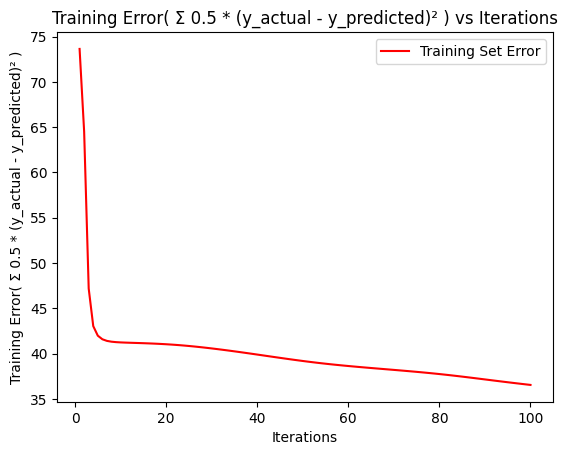

In [672]:
x=np.linspace(1,model_df.itr,model_df.itr)
plt.plot(x,np.array(model_df.train_error_hist),c='red',label="Training Set Error")
plt.xlabel("Iterations")
plt.ylabel("Training Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Training Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

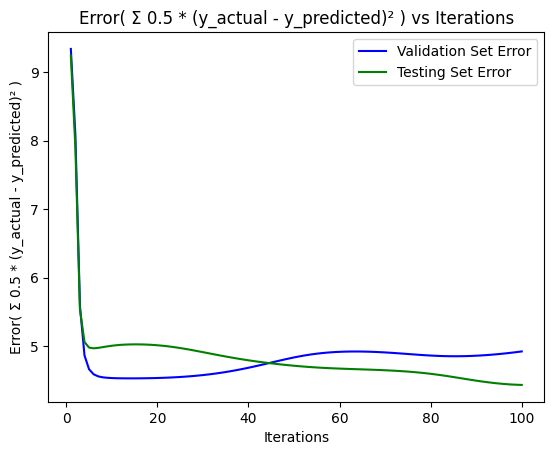

In [673]:
plt.plot(x,np.array(model_df.val_error_hist),c='blue',label="Validation Set Error")
plt.plot(x,np.array(model_df.test_error_hist),c='green',label="Testing Set Error")
plt.xlabel("Iterations")
plt.ylabel("Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

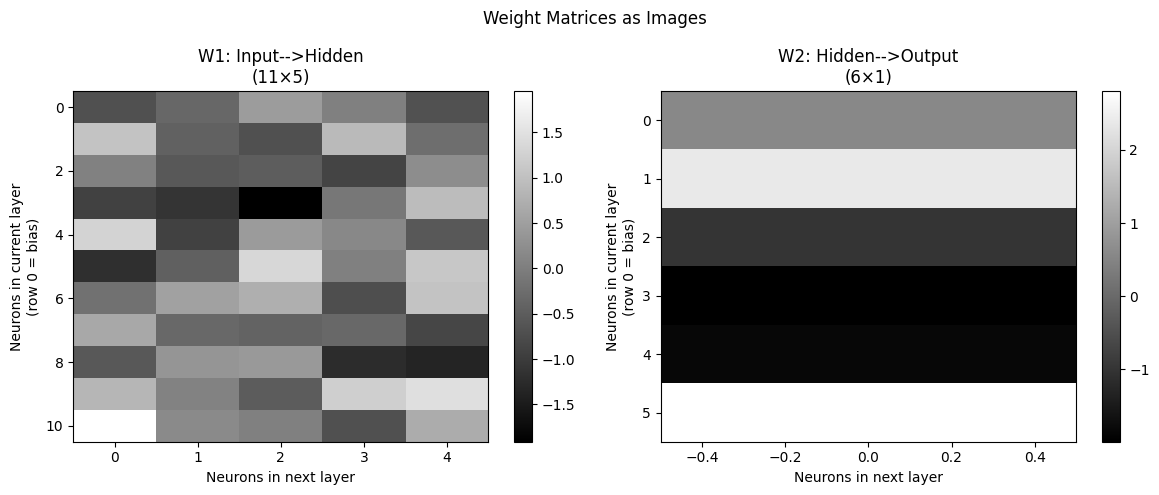

In [674]:
model_df.plot_weights()

In [675]:
print("On Cleveland:-",end='')
model_df.confusion_mat(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1])
print("Accuracy:",model_df.find_accuracy(clv_q4_scal.iloc[:,:-1],clv_q4_scal.iloc[:,-1]))
print("\nOn Hungarian:-",end='')
model_df.confusion_mat(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1])
print("Accuracy :",model_df.find_accuracy(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1]))
print("\nOn Switz:-",end='')
model_df.confusion_mat(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1])
print("Accuracy :",model_df.find_accuracy(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1]))
print("\nOn VA:-",end='')
model_df.confusion_mat(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1])
print("Accuracy :",model_df.find_accuracy(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1]))

On Cleveland:-
Confusion Matrix:-
 [TP FP] :  [111  26]
 [FN TN] :  [ 28 138]
Accuracy: 82.17821782178218

On Hungarian:-
Confusion Matrix:-
 [TP FP] :  [74 24]
 [FN TN] :  [ 24 139]
Accuracy : 81.60919540229885

On Switz:-
Confusion Matrix:-
 [TP FP] :  [38  0]
 [FN TN] :  [7 1]
Accuracy : 84.78260869565217

On VA:-
Confusion Matrix:-
 [TP FP] :  [95 23]
 [FN TN] :  [6 6]
Accuracy : 77.6923076923077


## Discussion

### Cross-Dataset Generalization
- **Hungarian-trained** model generalized best (~81-84% across datasets),
  likely due to having the largest dataset (261 samples).
- **Switzerland-trained** model failed on other datasets (37-45%),
  stopping at iteration 1 with 100% training accuracy — clear overfitting
  due to small dataset size.
- **VA-trained** model showed moderate generalization (71-79%),
  suggesting partial feature overlap with other datasets.
- **Cleveland-trained** model performed consistently (77-84%),
  comparable to Hungarian despite fewer samples.

### Combined Dataset Training
Training on all four datasets achieved ~80% test accuracy, comparable
to the best individual trainer (Hungarian). The larger combined dataset
reduced overfitting risk and improved generalization across unseen data,
suggesting that dataset diversity is more beneficial than size alone.

### Key Takeaway
Models trained on larger or more diverse datasets generalize significantly
better. Switzerland's failure highlights the danger of overfitting on
small datasets, while combined training demonstrates that pooling datasets
is a reliable strategy when individual datasets are limited.

# SETTINGS 2
- Increasing complexity of the model (Setting-2): Same as Setting-1, with number of hidden layers is changed to 2 with hidden nodes [5, 3]. 

In [676]:
clv_q4_scal = clv_q4.copy()
mean = clv_q4_scal.iloc[:,:-1].mean()
std = clv_q4_scal.iloc[:,:-1].std(ddof=0)  
clv_q4_scal.iloc[:,:-1] = (clv_q4_scal.iloc[:,:-1] - mean) / std
hung_q4_scal=hung_q4.copy()
hung_q4_scal.iloc[:,:-1] = (hung_q4_scal.iloc[:,:-1] - mean) / std
switz_q4_scal=switz_q4.copy()
switz_q4_scal.iloc[:,:-1] = (switz_q4_scal.iloc[:,:-1] - mean) / std
va_q4_scal=va_q4.copy()
va_q4_scal.iloc[:,:-1] = (va_q4_scal.iloc[:,:-1] - mean) / std

In [677]:
model_set2=MLP(clv_q4_scal,num_hidden_layers=2,n_hidden=[5,3],lr=0.1,alpha=1,random_init=True,confusion_flag=True,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_set2.main()

Training the Multi-Layer Perceptron:-
Iteration 20....	Training Accuracy=53.71900826446281 	 Validation Accuracy=60.0
Confusion Matrix:-
 [TP FP] :  [0 0]
 [FN TN] :  [15 16]
Iteration 40....	Training Accuracy=53.71900826446281 	 Validation Accuracy=60.0
Confusion Matrix:-
 [TP FP] :  [0 0]
 [FN TN] :  [15 16]
Iteration 60....	Training Accuracy=80.99173553719008 	 Validation Accuracy=80.033333333333336
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]
Iteration 80....	Training Accuracy=83.05785123966942 	 Validation Accuracy=76.66666666666667
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]
Iteration 100....	Training Accuracy=83.88429752066116 	 Validation Accuracy=80.0
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]

Training ends at iteration no. 100
Error% on the Testing Data: 22.58064516129032


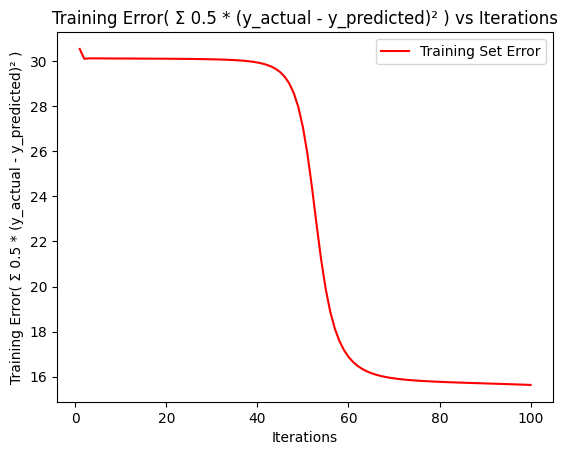

In [678]:
x=np.linspace(1,model_set2.itr,model_set2.itr)
plt.plot(x,np.array(model_set2.train_error_hist),c='red',label="Training Set Error")
plt.xlabel("Iterations")
plt.ylabel("Training Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Training Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

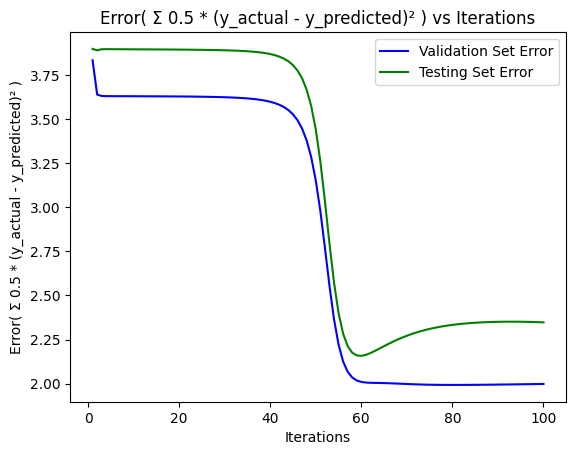

In [679]:
plt.plot(x,np.array(model_set2.val_error_hist),c='blue',label="Validation Set Error")
plt.plot(x,np.array(model_set2.test_error_hist),c='green',label="Testing Set Error")
plt.xlabel("Iterations")
plt.ylabel("Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

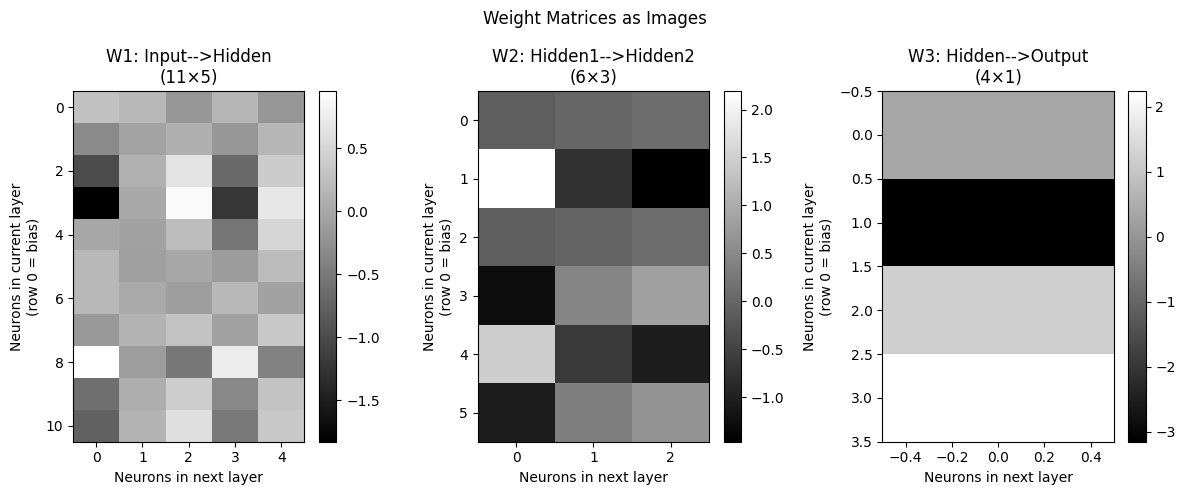

In [680]:
model_set2.plot_weights()

In [681]:
print("On Hungarian:-",end='')
model_set2.confusion_mat(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1])
print("Accuracy:",model_set2.find_accuracy(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1]))
print("\nOn Switzerland:-",end='')
model_set2.confusion_mat(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1])
print("Accuracy :",model_set2.find_accuracy(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1]))
print("\nOn VA:-",end='')
model_set2.confusion_mat(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1])
print("Accuracy :",model_set2.find_accuracy(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1]))

On Hungarian:-
Confusion Matrix:-
 [TP FP] :  [77 30]
 [FN TN] :  [ 21 133]
Accuracy: 80.45977011494253

On Switzerland:-
Confusion Matrix:-
 [TP FP] :  [38  1]
 [FN TN] :  [7 0]
Accuracy : 82.6086956521739

On VA:-
Confusion Matrix:-
 [TP FP] :  [90 23]
 [FN TN] :  [11  6]
Accuracy : 73.84615384615384


# SETTINGS 3
- Increasing generalization (Setting-3): In Setting-1 above, change [training : validation : testing] split to [60 : 20 : 20]. 

In [682]:
model_set3=MLP(clv_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=1,random_init=True,confusion_flag=True,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=60,val_seg=20)
model_set3.main()

Training the Multi-Layer Perceptron:-
Iteration 20....	Training Accuracy=81.76795580110497 	 Validation Accuracy=85.06666666666667
Confusion Matrix:-
 [TP FP] :  [22  6]
 [FN TN] :  [ 5 29]
Iteration 40....	Training Accuracy=81.76795580110497 	 Validation Accuracy=83.33333333333333
Confusion Matrix:-
 [TP FP] :  [22  9]
 [FN TN] :  [ 5 26]
Iteration 60....	Training Accuracy=82.32044198895028 	 Validation Accuracy=85.03333333333333
Confusion Matrix:-
 [TP FP] :  [22  9]
 [FN TN] :  [ 5 26]
Iteration 80....	Training Accuracy=82.87292817679558 	 Validation Accuracy=86.66666666666667
Confusion Matrix:-
 [TP FP] :  [22  9]
 [FN TN] :  [ 5 26]
Iteration 100....	Training Accuracy=83.97790055248619 	 Validation Accuracy=86.66666666666667
Confusion Matrix:-
 [TP FP] :  [21  8]
 [FN TN] :  [ 6 27]

Training ends at iteration no. 100
Error% on the Testing Data: 22.58064516129032


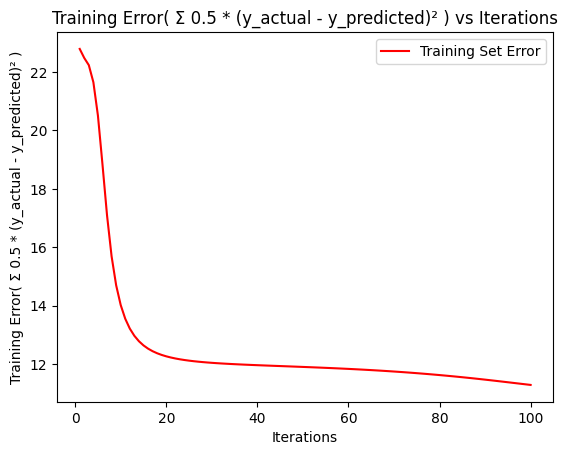

In [683]:
x=np.linspace(1,model_set3.itr,model_set3.itr)
plt.plot(x,np.array(model_set3.train_error_hist),c='red',label="Training Set Error")
plt.xlabel("Iterations")
plt.ylabel("Training Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Training Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

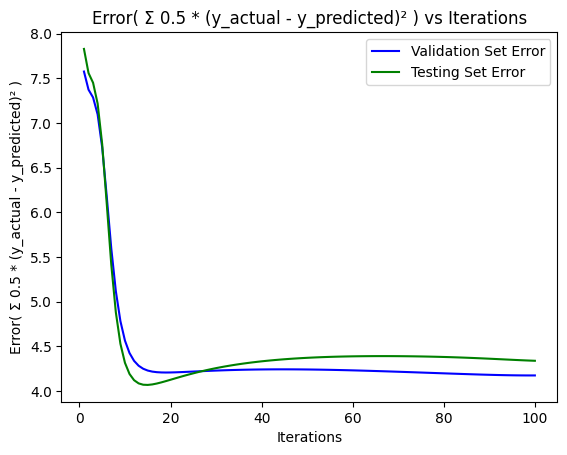

In [684]:
plt.plot(x,np.array(model_set3.val_error_hist),c='blue',label="Validation Set Error")
plt.plot(x,np.array(model_set3.test_error_hist),c='green',label="Testing Set Error")
plt.xlabel("Iterations")
plt.ylabel("Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

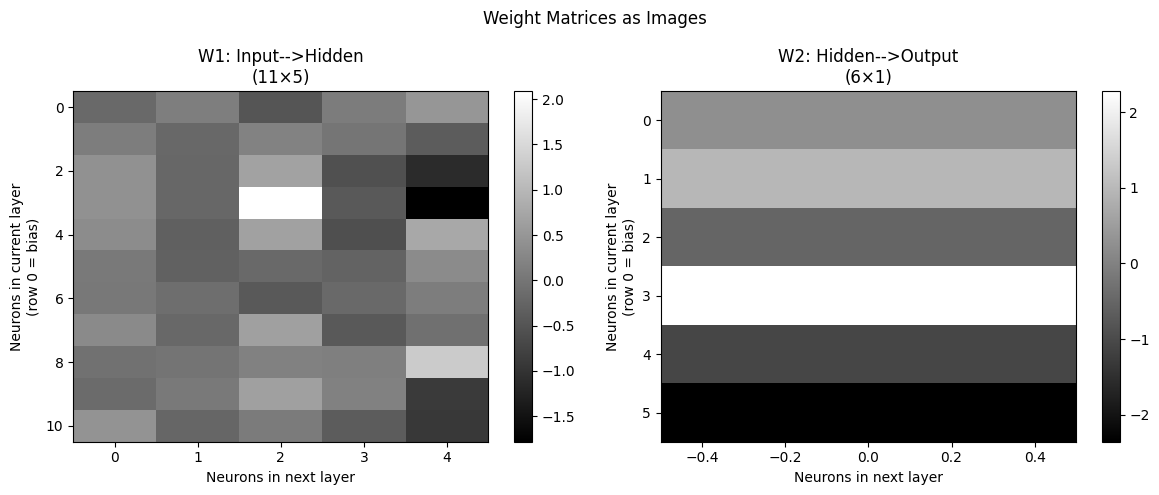

In [685]:
model_set3.plot_weights()

In [686]:
print("On Hungarian:-",end='')
model_set3.confusion_mat(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1])
print("Accuracy:",model_set3.find_accuracy(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1]))
print("\nOn Switzerland:-",end='')
model_set3.confusion_mat(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1])
print("Accuracy :",model_set3.find_accuracy(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1]))
print("\nOn VA:-",end='')
model_set3.confusion_mat(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1])
print("Accuracy :",model_set3.find_accuracy(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1]))

On Hungarian:-
Confusion Matrix:-
 [TP FP] :  [69 26]
 [FN TN] :  [ 29 137]
Accuracy: 78.9272030651341

On Switzerland:-
Confusion Matrix:-
 [TP FP] :  [39  0]
 [FN TN] :  [6 1]
Accuracy : 86.95652173913044

On VA:-
Confusion Matrix:-
 [TP FP] :  [89 22]
 [FN TN] :  [12  7]
Accuracy : 73.84615384615384


# SETTINGS 4
- Effect of learning rate value towards convergence (Setting-4): In Setting-1 above, change [α = 0.9], [LR_decay_freq = 20]. 

In [687]:
model_set4=MLP(clv_q4_scal,num_hidden_layers=1,n_hidden=[5],lr=0.1,alpha=0.9,lr_decay_freq=20,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10,random_init=True,confusion_flag=True)
model_set4.main()

Training the Multi-Layer Perceptron:-
Iteration 20....	Training Accuracy=82.23140495867769 	 Validation Accuracy=80.0333333333333
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]
Iteration 40....	Training Accuracy=82.23140495867769 	 Validation Accuracy=80.0
Confusion Matrix:-
 [TP FP] :  [12  4]
 [FN TN] :  [ 3 12]
Iteration 60....	Training Accuracy=82.64462809917356 	 Validation Accuracy=80.0
Confusion Matrix:-
 [TP FP] :  [12  3]
 [FN TN] :  [ 3 13]
Iteration 80....	Training Accuracy=83.47107438016529 	 Validation Accuracy=80.0
Confusion Matrix:-
 [TP FP] :  [12  3]
 [FN TN] :  [ 3 13]
Iteration 100....	Training Accuracy=83.88429752066116 	 Validation Accuracy=86.66666666666667
Confusion Matrix:-
 [TP FP] :  [12  2]
 [FN TN] :  [ 3 14]

Training ends at iteration no. 100
Error% on the Testing Data: 16.129032258064512


For Training Set:-


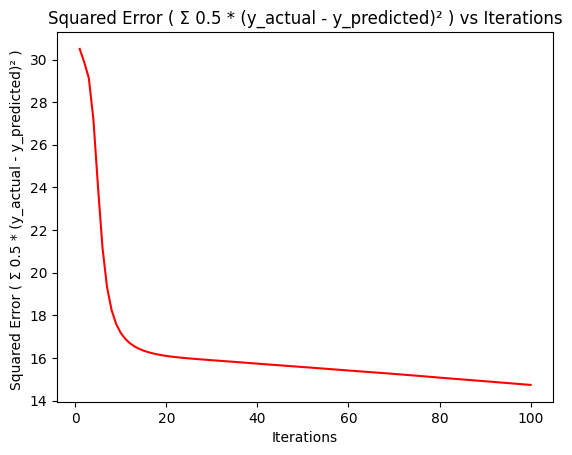

In [688]:
print("For Training Set:-")
model_set4.plot_error(model_set4.train_error_hist)

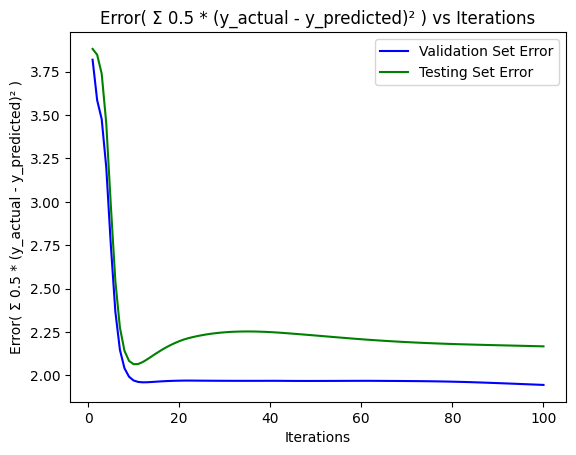

In [689]:
x=np.linspace(1,model_set4.itr,model_set4.itr)
plt.plot(x,np.array(model_set4.val_error_hist),c='blue',label="Validation Set Error")
plt.plot(x,np.array(model_set4.test_error_hist),c='green',label="Testing Set Error")
plt.xlabel("Iterations")
plt.ylabel("Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

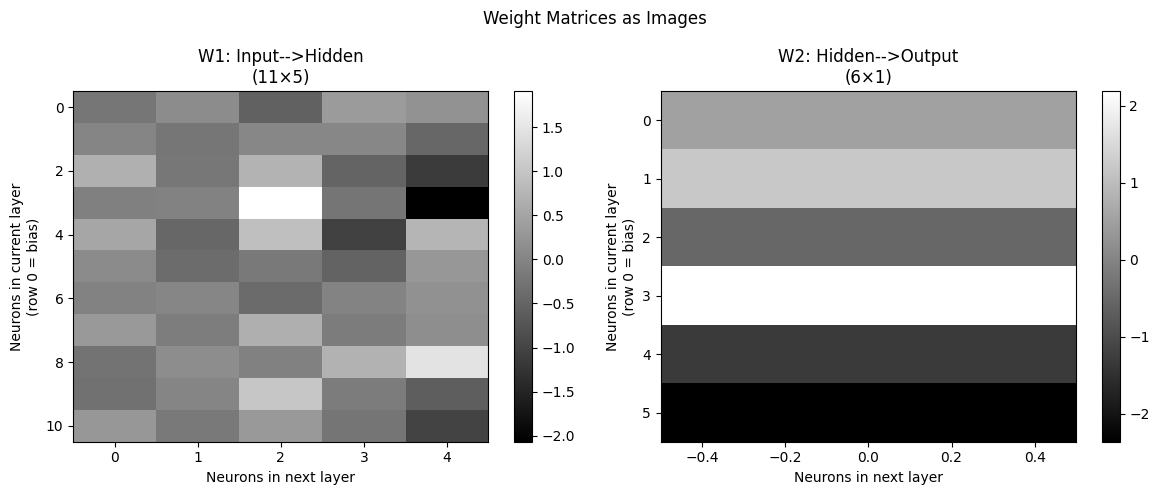

In [690]:
model_set4.plot_weights()

In [691]:
print("On Hungarian:-",end='')
model_set4.confusion_mat(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1])
print("Accuracy:",model_set4.find_accuracy(hung_q4_scal.iloc[:,:-1],hung_q4_scal.iloc[:,-1]))
print("\nOn Switzerland:-",end='')
model_set4.confusion_mat(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1])
print("Accuracy :",model_set4.find_accuracy(switz_q4_scal.iloc[:,:-1],switz_q4_scal.iloc[:,-1]))
print("\nOn VA:-",end='')
model_set4.confusion_mat(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1])
print("Accuracy :",model_set4.find_accuracy(va_q4_scal.iloc[:,:-1],va_q4_scal.iloc[:,-1]))

On Hungarian:-
Confusion Matrix:-
 [TP FP] :  [75 31]
 [FN TN] :  [ 23 132]
Accuracy: 79.3103448275862

On Switzerland:-
Confusion Matrix:-
 [TP FP] :  [40  0]
 [FN TN] :  [5 1]
Accuracy : 89.1304347826087

On VA:-
Confusion Matrix:-
 [TP FP] :  [89 22]
 [FN TN] :  [12  7]
Accuracy : 73.84615384615384


# SETTINGS 5
- Multiclass classification (Setting-5): Now, in Setting-2, consider all heart-disease classes 
separately. 

In [692]:
clv_q5 = clv_pcsd.copy()
mean = clv_q5.iloc[:,:-1].mean()
std = clv_q5.iloc[:,:-1].std(ddof=0)  
clv_q5.iloc[:,:-1] = (clv_q5.iloc[:,:-1] - mean) / std
hung_q5=hung_pcsd.copy()
hung_q5.iloc[:,:-1] = (hung_q5.iloc[:,:-1] - mean) / std
switz_q5=switz_pcsd.copy()
switz_q5.iloc[:,:-1] = (switz_q5.iloc[:,:-1] - mean) / std
va_q5=va_pcsd.copy()
va_q5.iloc[:,:-1] = (va_q5.iloc[:,:-1] - mean) / std

In [693]:
model_set5=MLP(clv_q5,num_hidden_layers=2,n_hidden=[5,3],lr=0.1,alpha=1,random_init=True,lr_decay_freq=np.inf,maxIter=100,maxErr=5,percentOverfit=30,train_seg=80,val_seg=10)
model_set5.main()

Training the Multi-Layer Perceptron:-
Iteration 100....	Training Accuracy=60.743801652892564 	 Validation Accuracy=66.66666666666667
Training ends at iteration no. 100
Error% on the Testing Data: 51.61290322580645


For the training data:-


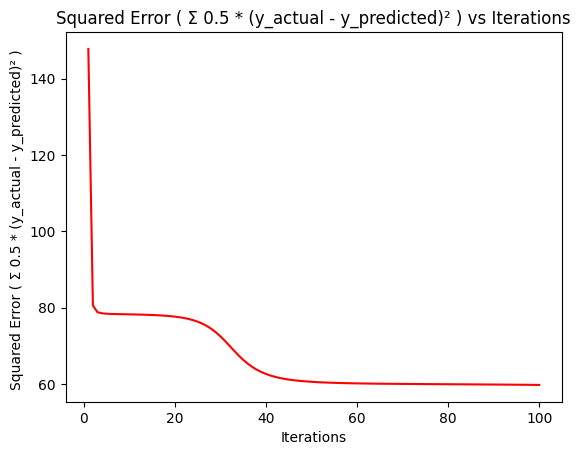

In [694]:
print("For the training data:-")
model_set5.plot_error(model_set5.train_error_hist)

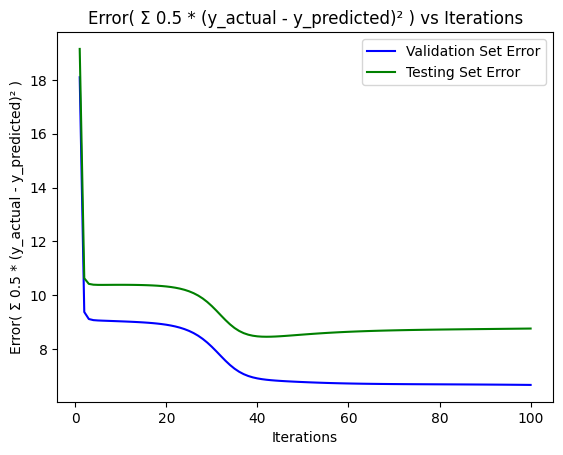

In [695]:
x=np.linspace(1,model_set5.itr,model_set5.itr)
plt.plot(x,np.array(model_set5.val_error_hist),c='blue',label="Validation Set Error")
plt.plot(x,np.array(model_set5.test_error_hist),c='green',label="Testing Set Error")
plt.xlabel("Iterations")
plt.ylabel("Error( Σ 0.5 * (y_actual - y_predicted)² )")
plt.title("Error( Σ 0.5 * (y_actual - y_predicted)² ) vs Iterations")
plt.legend()
plt.show()

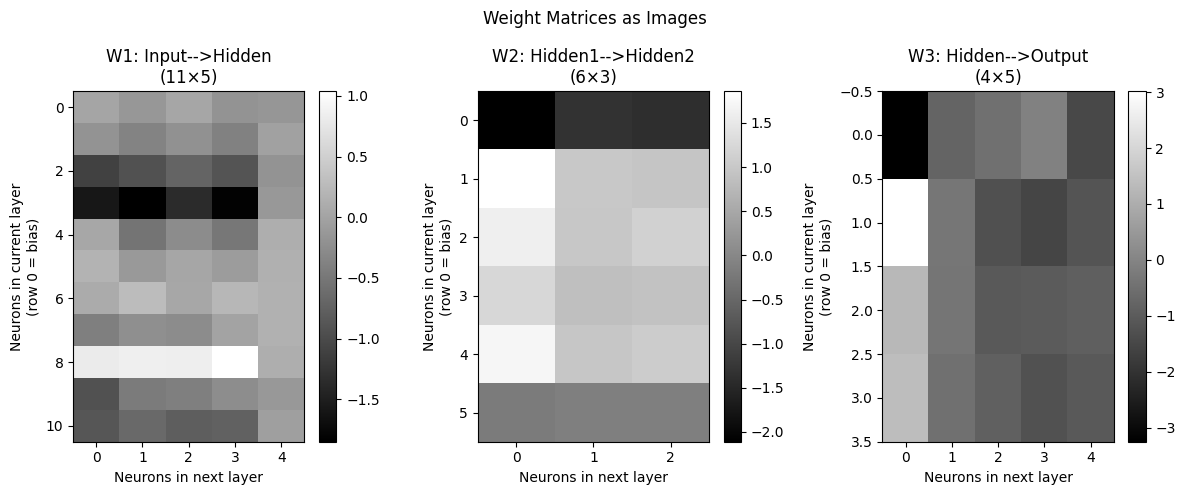

In [696]:
model_set5.plot_weights()

In [697]:
pred_df=model_set5.predicted_df()
pred_df["y_actual"].value_counts()

y_actual
0.0    164
1.0     55
2.0     36
3.0     35
4.0     13
Name: count, dtype: int64

In [698]:
pred_df["y_predicted"].value_counts()

y_predicted
0    198
3     91
1     14
Name: count, dtype: int64

## Setting-2 (Binary) vs Setting-5 (Multiclass)

| Metric | Setting-2 (Binary) | Setting-5 (Multiclass) |
|--------|-------------------|----------------------|
| Final Training Accuracy | 83.88% | 60.74% |
| Final Validation Accuracy | 80.0% | 66.67% |
| Test Accuracy | 77.42% | 48.39% |

### Key Observations

- Binary classification significantly outperforms multiclass (77.42% vs 48.39%).
- Setting-5 suffers from severe class imbalance — class 0 has 164 samples 
  while class 4 has only 13, causing the model to predominantly predict 
  the majority class.
- Setting-2 was stuck until iteration 60 before escaping a local minimum, 
  highlighting the slow convergence of sigmoid activations.
- With the same 100 iterations, multiclass has far more weights to optimize 
  (5 output nodes vs 1), making convergence harder.